In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Testing images:", x_test.shape)
print("Testing labels:", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1935s 11us/step
Training images: (50000, 32, 32, 3)
Training labels: (50000, 1)
Testing images: (10000, 32, 32, 3)
Testing labels: (10000, 1)


In [ ]:
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

In [ ]:
x_train = tf.image.resize(x_train, [64, 64])
x_test = tf.image.resize(x_test, [64, 64])


x_train = x_train / 255.0
x_test = x_test / 255.0

print("After preprocessing:")
print("Training images:", x_train.shape)
print("Testing images:", x_test.shape)

After preprocessing:
Training images: (50000, 64, 64, 3)
Testing images: (10000, 64, 64, 3)


In [ ]:
y_train = y_train.flatten()
y_test = y_test.flatten()

x_val = x_train[-5000:]
y_val = y_train[-5000:]

x_train = x_train[:-5000]
y_train = y_train[:-5000]

print("Training set:", x_train.shape)
print("Validation set:", x_val.shape)
print("Testing set:", x_test.shape)

Training set: (45000, 64, 64, 3)
Validation set: (5000, 64, 64, 3)
Testing set: (10000, 64, 64, 3)


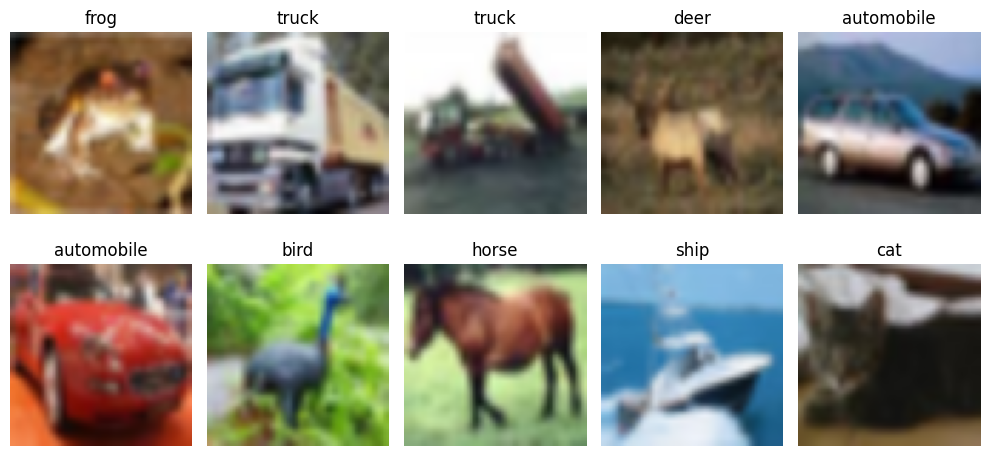

In [ ]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
model = models.Sequential([

    # First convolution block
    layers.Conv2D(32, (3, 3), activation='relu',
                  input_shape=(64, 64, 3)),
    layers.MaxPooling2D((2, 2)),

    # Second convolution block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Third convolution block
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Fully connected layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),

    # Output layer
    layers.Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 684,490 (2.61 MB)

 Trainable params: 684,490 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(x_val, y_val)
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 16ms/step - accuracy: 0.4503 - loss: 1.5169 - val_accuracy: 0.5656 - val_loss: 1.2393
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.6155 - loss: 1.0921 - val_accuracy: 0.6544 - val_loss: 0.9858
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.6797 - loss: 0.9130 - val_accuracy: 0.6906 - val_loss: 0.8883
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.7238 - loss: 0.7937 - val_accuracy: 0.7094 - val_loss: 0.8348
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.7571 - loss: 0.7031 - val_accuracy: 0.7236 - val_loss: 0.8065
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.7821 - loss: 0.6243 - val_accuracy: 0.7324 - val_loss: 0.7894
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.8068 - loss: 0.5506 - val_accuracy: 0.7250 - val_loss: 0.8042
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.8316 - loss: 0.4794 - val_ac

In [ ]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Testing Loss:", test_loss)
print("Testing Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7152 - loss: 1.0103
Testing Loss: 1.0102952718734741
Testing Accuracy: 0.7152000069618225


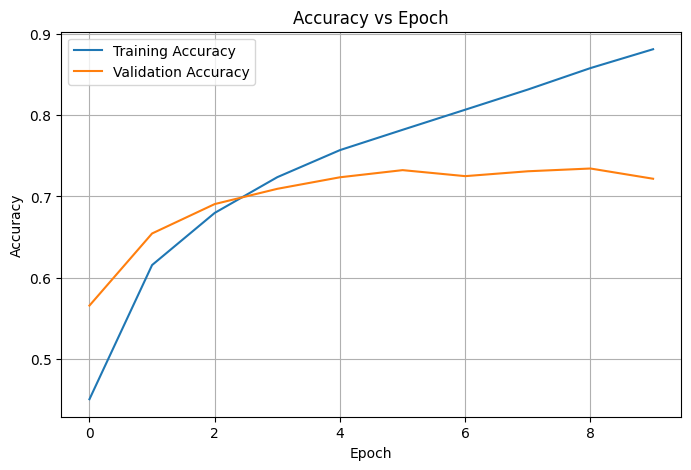

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epoch')
plt.legend()
plt.grid()
plt.show()

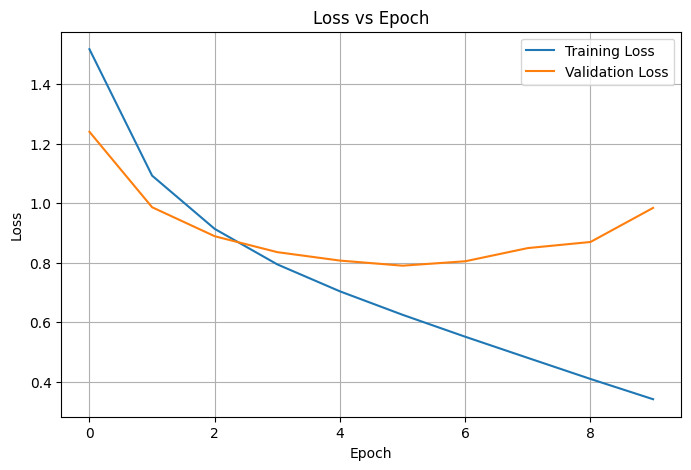

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epoch')
plt.legend()
plt.grid()
plt.show()

In [ ]:
predictions = model.predict(x_test)

predicted_labels = np.argmax(predictions, axis=1)

print("Predicted labels:")
print(predicted_labels[:20])

print("Actual labels:")
print(y_test[:20])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Predicted labels:
[3 8 1 0 4 6 1 6 3 1 0 9 5 7 9 8 5 5 8 6]
Actual labels:
[3 8 8 0 6 6 1 6 3 1 0 9 5 7 9 8 5 7 8 6]


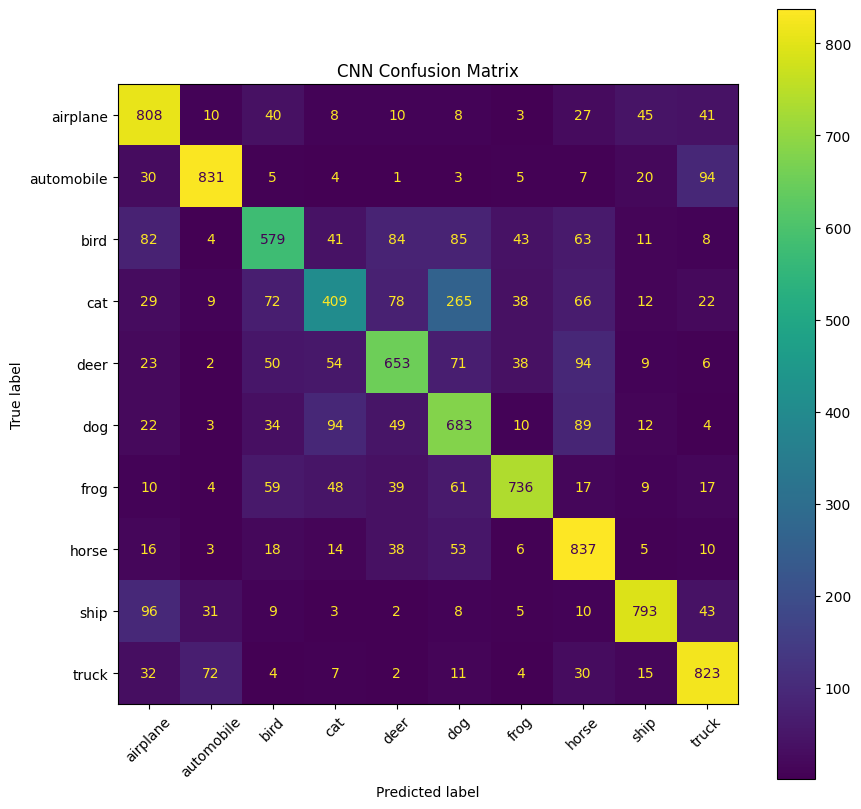

In [ ]:
cm = confusion_matrix(y_test, predicted_labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(10, 10))

disp.plot(ax=ax, xticks_rotation=45)

plt.title("CNN Confusion Matrix")
plt.show()

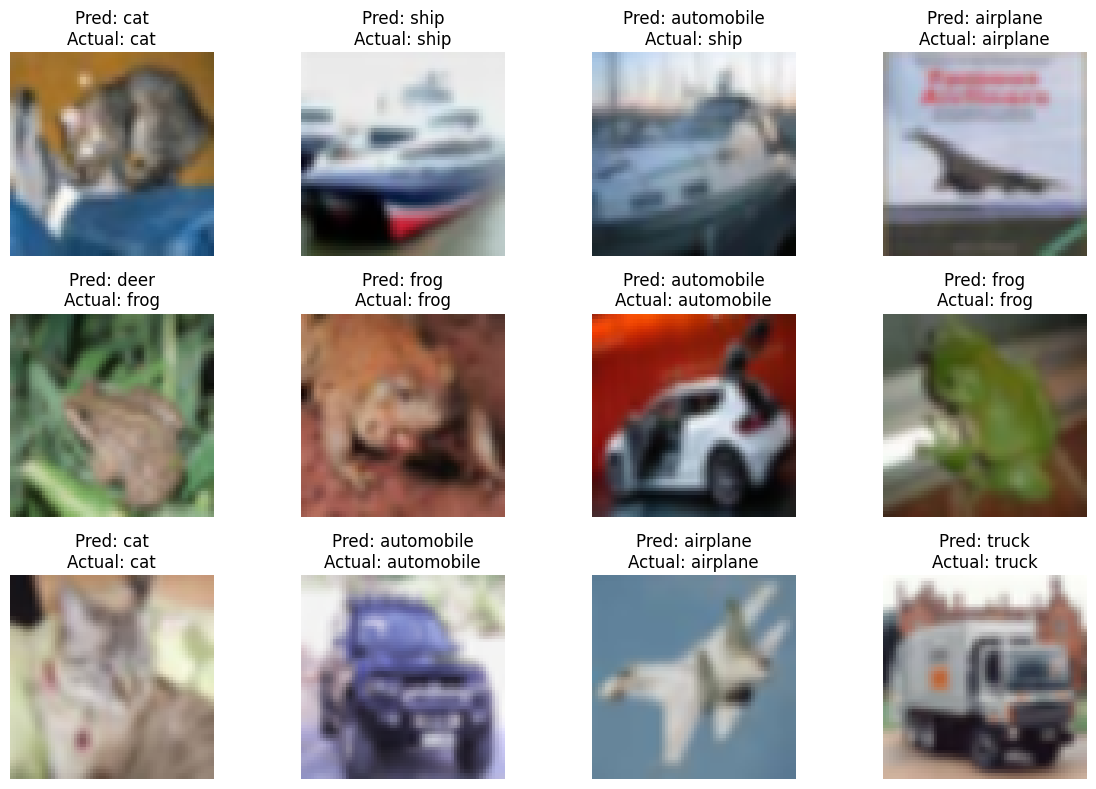

In [ ]:
plt.figure(figsize=(12, 8))

for i in range(12):

    plt.subplot(3, 4, i + 1)

    plt.imshow(x_test[i])

    predicted = class_names[predicted_labels[i]]
    actual = class_names[y_test[i]]

    plt.title(f"Pred: {predicted}\nActual: {actual}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
misclassified = np.where(predicted_labels != y_test)[0]

print("Number of misclassified images:",
      len(misclassified))

Number of misclassified images: 2848


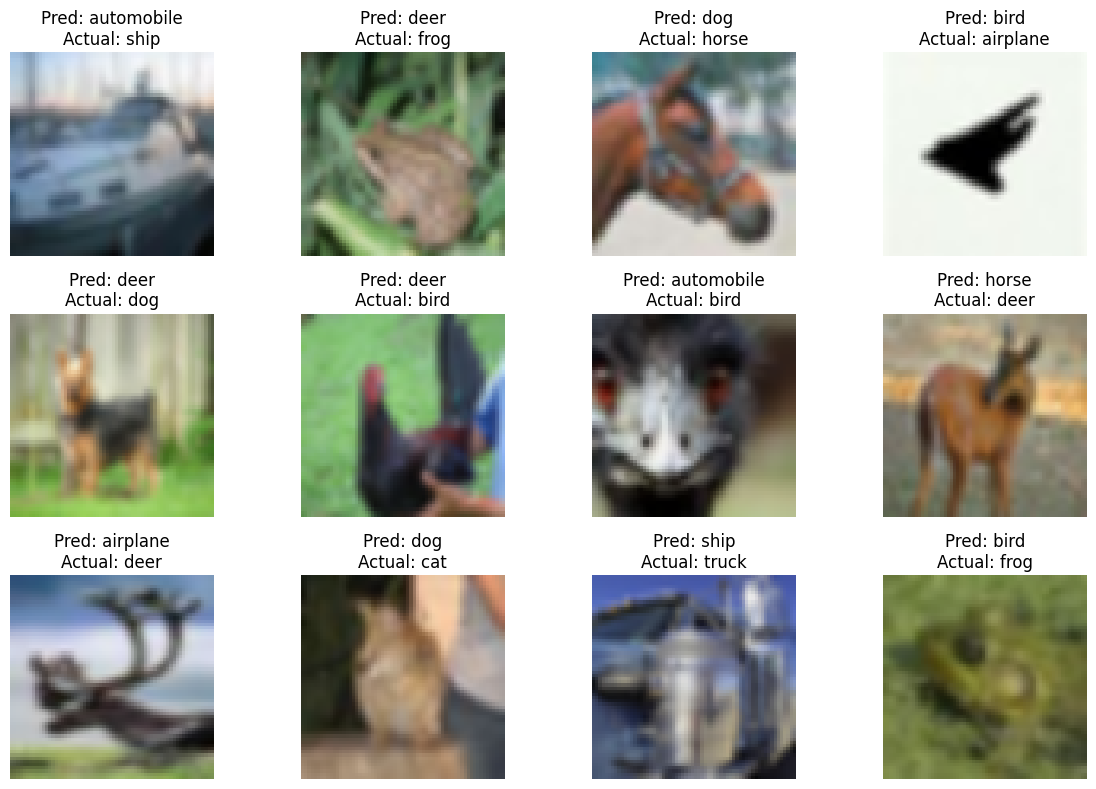

In [ ]:
plt.figure(figsize=(12, 8))

for i in range(min(12, len(misclassified))):

    index = misclassified[i]

    plt.subplot(3, 4, i + 1)

    plt.imshow(x_test[index])

    predicted = class_names[predicted_labels[index]]
    actual = class_names[y_test[index]]

    plt.title(f"Pred: {predicted}\nActual: {actual}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
print("===== CNN PERFORMANCE =====")

print("Final Training Accuracy:",
      history.history['accuracy'][-1])

print("Final Validation Accuracy:",
      history.history['val_accuracy'][-1])

print("Final Training Loss:",
      history.history['loss'][-1])

print("Final Validation Loss:",
      history.history['val_loss'][-1])

print("Testing Accuracy:",
      test_accuracy)

print("Testing Loss:",
      test_loss)

===== CNN PERFORMANCE =====
Final Training Accuracy: 0.8813111186027527
Final Validation Accuracy: 0.7218000292778015
Final Training Loss: 0.34054994583129883
Final Validation Loss: 0.9836309552192688
Testing Accuracy: 0.7152000069618225
Testing Loss: 1.0102952718734741
